# Crypto Market Risk Analytics: BTC vs BNB

This notebook validates the included Binance.US data and compares BTC/USDT with BNB/USDT from November 2022 through October 2025.

**Risk definitions**

- Close-to-close return: log change between consecutive daily closes.
- Daily volatility: standard deviation of close-to-close daily log returns.
- Rolling volatility: 30-day daily volatility, annualized with a 365-day factor.
- Intraday return: `(daily close - daily open) / daily open`.
- Daily range: `(daily high - daily low) / daily open`.

The analysis is descriptive and is not investment advice.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"BTCUSDT": "#F28E2B", "BNBUSDT": "#4E79A7"}
DATA_DIR = Path("../data/processed")

Matplotlib is building the font cache; this may take a moment.


## 1. Load and prepare the data

In [2]:
frames = []
for parquet_path in sorted(DATA_DIR.glob("*_30m.parquet")):
    frame = pd.read_parquet(parquet_path)
    frame["open_time"] = pd.to_datetime(frame["open_time"])
    frame["symbol"] = frame["symbol"].str.upper()
    frames.append(frame)

market = pd.concat(frames, ignore_index=True).sort_values(["symbol", "open_time"])

overview = (
    market.groupby("symbol")
    .agg(rows=("open_time", "size"), start=("open_time", "min"), end=("open_time", "max"))
)
overview

,rows,start,end
symbol,,,
BNBUSDT,52594,2022-11-01,2025-10-31 23:30:00
BTCUSDT,52594,2022-11-01,2025-10-31 23:30:00


## 2. Data-quality checks

In [3]:
numeric_columns = [
    "open", "high", "low", "close", "volume", "quote_asset_volume",
    "num_trades", "taker_buy_base", "taker_buy_quote",
]

quality_rows = []
gap_rows = []
for symbol, frame in market.groupby("symbol"):
    frame = frame.sort_values("open_time").copy()
    numeric = frame[numeric_columns].apply(pd.to_numeric, errors="coerce")
    invalid_ohlc = (
        (numeric["high"] < numeric[["open", "close", "low"]].max(axis=1))
        | (numeric["low"] > numeric[["open", "close", "high"]].min(axis=1))
    )
    quality_rows.append(
        {
            "symbol": symbol,
            "duplicates": frame.duplicated(["symbol", "open_time"]).sum(),
            "missing_values": frame.isna().sum().sum(),
            "numeric_parse_errors": numeric.isna().sum().sum(),
            "negative_rows": (numeric < 0).any(axis=1).sum(),
            "invalid_ohlc_rows": invalid_ohlc.sum(),
        }
    )

    differences = frame["open_time"].diff()
    for index in differences[differences > pd.Timedelta(minutes=30)].index:
        gap_end = frame.loc[index, "open_time"]
        gap_start = gap_end - differences.loc[index]
        gap_rows.append(
            {
                "symbol": symbol,
                "last_candle_before_gap": gap_start,
                "first_candle_after_gap": gap_end,
                "missing_30m_candles": int(differences.loc[index] / pd.Timedelta(minutes=30)) - 1,
            }
        )

quality = pd.DataFrame(quality_rows).set_index("symbol")
gaps = pd.DataFrame(gap_rows)
display(quality)
display(gaps)

/var/folders/qw/v1mp9h4n1f987rsx0zff8yvc0000gn/T/ipykernel_19735/457693922.py:27: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  for index in differences[differences > pd.Timedelta(minutes=30)].index:
/var/folders/qw/v1mp9h4n1f987rsx0zff8yvc0000gn/T/ipykernel_19735/457693922.py:35: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  "missing_30m_candles": int(differences.loc[index] / pd.Timedelta(minutes=30)) - 1,
/var/folders/qw/v1mp9h4n1f987rsx0zff8yvc0000gn/T/ipykernel_19735/457693922.py:27: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.

,duplicates,missing_values,numeric_parse_errors,negative_rows,invalid_ohlc_rows
symbol,,,,,
BNBUSDT,0,0,0,0,0
BTCUSDT,0,0,0,0,0


,symbol,last_candle_before_gap,first_candle_after_gap,missing_30m_candles
0,BNBUSDT,2023-02-06 04:30:00,2023-02-06 12:00:00,14
1,BTCUSDT,2023-02-06 04:30:00,2023-02-06 12:00:00,14


The files contain no duplicate keys, missing required values, negative market fields, or invalid OHLC relationships. Both assets share one source-data gap on February 6, 2023. The missing candles are disclosed rather than imputed because invented prices or volumes would distort risk estimates.

## 3. Daily prices and close-to-close risk

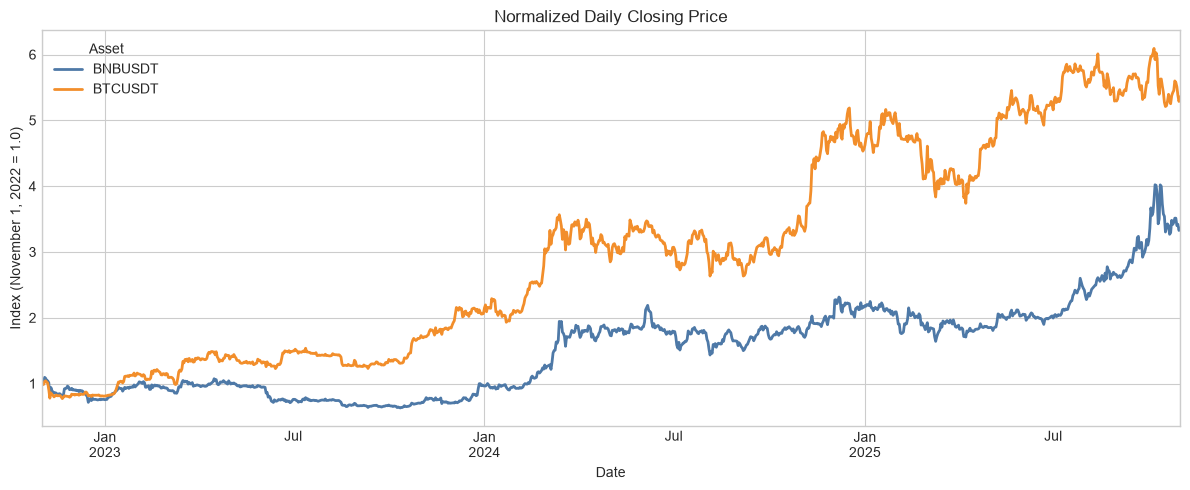

In [4]:
daily_close = (
    market.set_index("open_time")
    .groupby("symbol")["close"]
    .resample("D")
    .last()
    .unstack(0)
    .dropna()
)

log_returns = np.log(daily_close / daily_close.shift(1)).dropna()
normalized_close = daily_close / daily_close.iloc[0]

ax = normalized_close.plot(figsize=(12, 5), color=[COLORS[column] for column in normalized_close.columns], linewidth=2)
ax.set_title("Normalized Daily Closing Price")
ax.set_xlabel("Date")
ax.set_ylabel("Index (November 1, 2022 = 1.0)")
ax.legend(title="Asset")
plt.tight_layout()
plt.show()

In [5]:
risk_summary = pd.DataFrame(
    {
        "ending_price_index": normalized_close.iloc[-1],
        "mean_daily_log_return": log_returns.mean(),
        "daily_volatility": log_returns.std(),
        "annualized_volatility": log_returns.std() * np.sqrt(365),
        "worst_daily_log_return": log_returns.min(),
        "best_daily_log_return": log_returns.max(),
    }
)
risk_summary

,ending_price_index,mean_daily_log_return,daily_volatility,annualized_volatility,worst_daily_log_return,best_daily_log_return
symbol,,,,,,
BNBUSDT,3.3617,0.0011,0.0283,0.5406,-0.2093,0.1595
BTCUSDT,5.3574,0.0015,0.0247,0.4717,-0.1521,0.1138


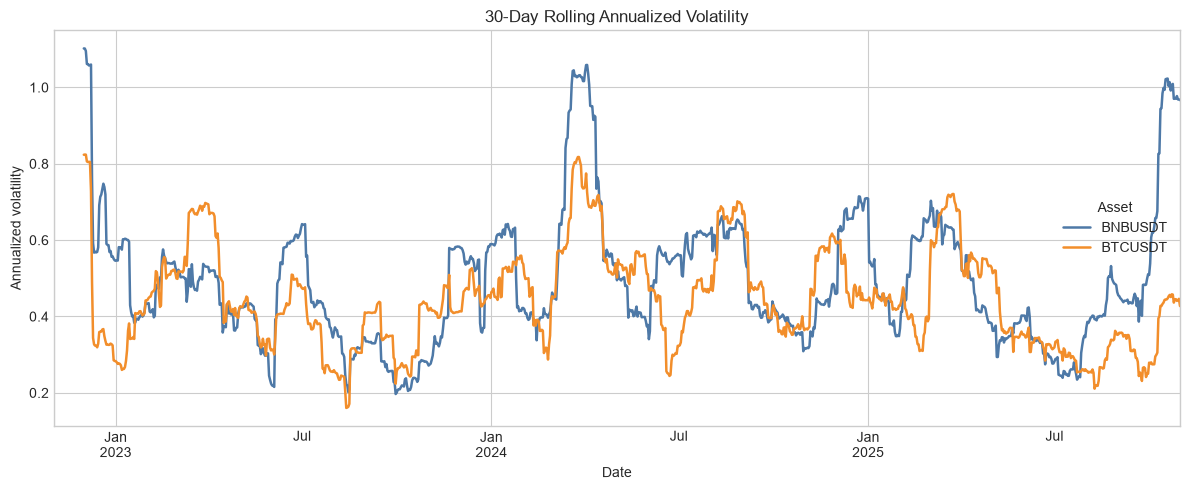

In [6]:
rolling_volatility = log_returns.rolling(30).std() * np.sqrt(365)

ax = rolling_volatility.plot(
    figsize=(12, 5),
    color=[COLORS[column] for column in rolling_volatility.columns],
    linewidth=1.8,
)
ax.set_title("30-Day Rolling Annualized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility")
ax.legend(title="Asset")
plt.tight_layout()
plt.show()

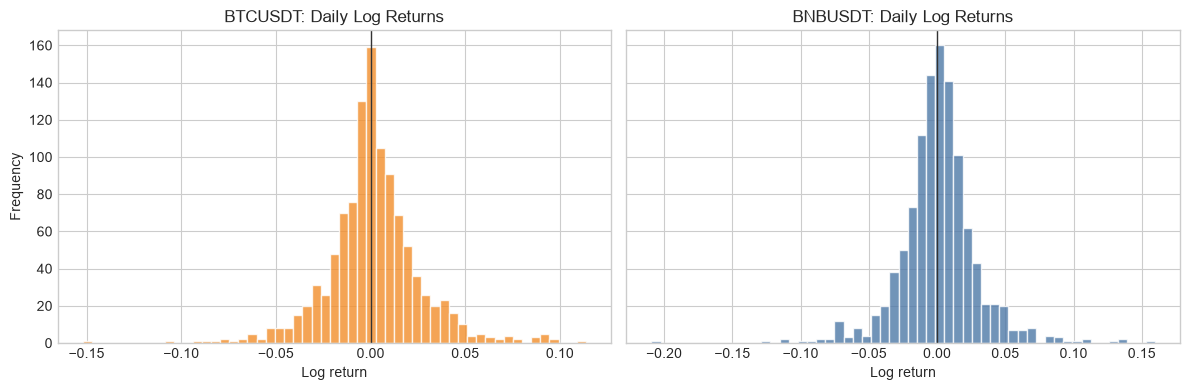

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, symbol in zip(axes, ["BTCUSDT", "BNBUSDT"]):
    axis.hist(log_returns[symbol], bins=55, color=COLORS[symbol], alpha=0.8, edgecolor="white")
    axis.axvline(0, color="#333333", linewidth=1)
    axis.set_title(f"{symbol}: Daily Log Returns")
    axis.set_xlabel("Log return")
axes[0].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 4. Seasonal and weekday patterns

In [8]:
daily_ohlc = (
    market.set_index("open_time")
    .groupby("symbol")
    .resample("D")
    .agg(open=("open", "first"), high=("high", "max"), low=("low", "min"), close=("close", "last"))
    .dropna()
    .reset_index()
)
daily_ohlc["intraday_return"] = (daily_ohlc["close"] - daily_ohlc["open"]) / daily_ohlc["open"]
daily_ohlc["daily_range"] = (daily_ohlc["high"] - daily_ohlc["low"]) / daily_ohlc["open"]
daily_ohlc["month"] = daily_ohlc["open_time"].dt.month
daily_ohlc["weekday"] = daily_ohlc["open_time"].dt.day_name()
daily_ohlc["season"] = daily_ohlc["month"].map(
    {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall"}
)

seasonal = daily_ohlc.groupby(["symbol", "season"])[["intraday_return", "daily_range"]].mean()
seasonal

/var/folders/qw/v1mp9h4n1f987rsx0zff8yvc0000gn/T/ipykernel_19735/224759018.py:5: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .agg(open=("open", "first"), high=("high", "max"), low=("low", "min"), close=("close", "last"))


intraday_return  daily_range
symbol  season                              
BNBUSDT Fall             0.0015       0.0445
        Spring           0.0020       0.0413
        Summer          -0.0007       0.0412
        Winter           0.0018       0.0462
BTCUSDT Fall             0.0029       0.0322
        Spring           0.0021       0.0407
        Summer          -0.0003       0.0436
        Winter           0.0026       0.0354

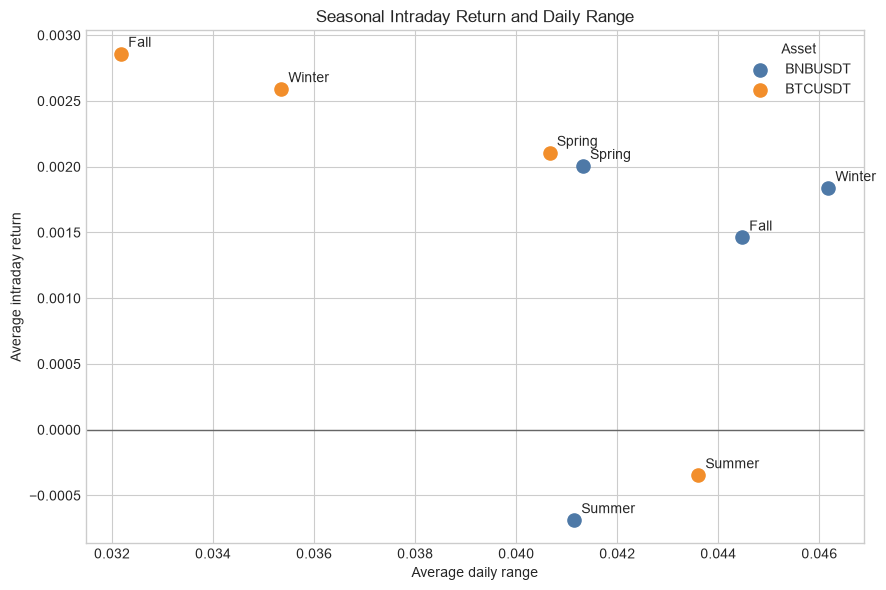

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
for symbol, frame in seasonal.reset_index().groupby("symbol"):
    ax.scatter(frame["daily_range"], frame["intraday_return"], s=90, label=symbol, color=COLORS[symbol])
    for row in frame.itertuples():
        ax.annotate(row.season, (row.daily_range, row.intraday_return), xytext=(5, 5), textcoords="offset points")
ax.axhline(0, color="#666666", linewidth=1)
ax.set_title("Seasonal Intraday Return and Daily Range")
ax.set_xlabel("Average daily range")
ax.set_ylabel("Average intraday return")
ax.legend(title="Asset")
plt.tight_layout()
plt.show()

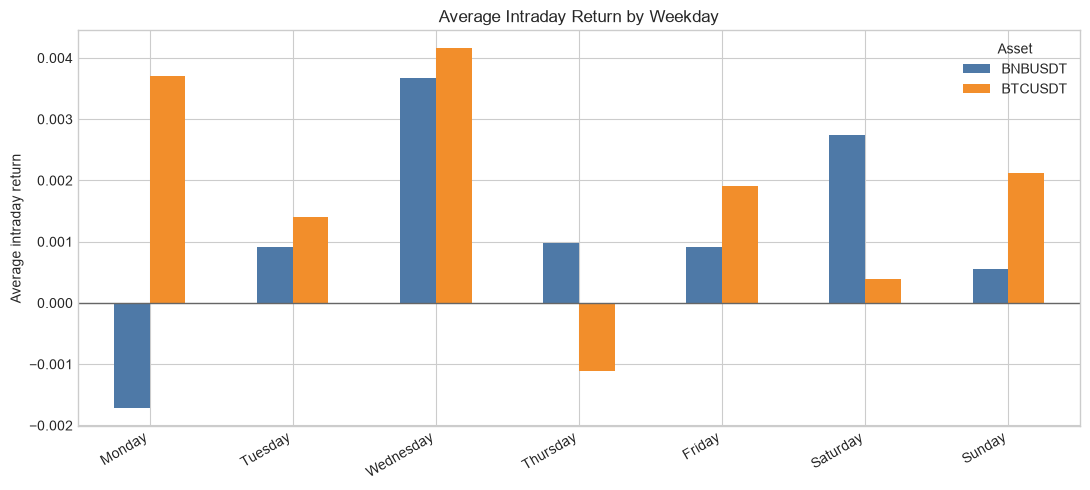

symbol,BNBUSDT,BTCUSDT
weekday,,
Monday,-0.0017,0.0037
Tuesday,0.0009,0.0014
Wednesday,0.0037,0.0042
Thursday,0.0010,-0.0011
Friday,0.0009,0.0019
Saturday,0.0027,0.0004
Sunday,0.0006,0.0021


In [10]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = (
    daily_ohlc.groupby(["weekday", "symbol"])["intraday_return"]
    .mean()
    .unstack("symbol")
    .reindex(weekday_order)
)

ax = weekday_summary.plot(
    kind="bar",
    figsize=(11, 5),
    color=[COLORS[column] for column in weekday_summary.columns],
)
ax.axhline(0, color="#666666", linewidth=1)
ax.set_title("Average Intraday Return by Weekday")
ax.set_xlabel("")
ax.set_ylabel("Average intraday return")
ax.legend(title="Asset")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

weekday_summary

## 5. Portfolio conclusions

In [11]:
btc_index = risk_summary.loc["BTCUSDT", "ending_price_index"]
bnb_index = risk_summary.loc["BNBUSDT", "ending_price_index"]
btc_vol = risk_summary.loc["BTCUSDT", "daily_volatility"]
bnb_vol = risk_summary.loc["BNBUSDT", "daily_volatility"]

display(Markdown(f"""
- BTC produced the stronger price increase over the sample: **{btc_index:.2f}x** the starting close versus **{bnb_index:.2f}x** for BNB.
- BNB had the higher close-to-close daily volatility: **{bnb_vol:.2%}** versus **{btc_vol:.2%}** for BTC.
- Both assets had negative average intraday returns in summer. BTC's largest average daily range occurred in summer, while BNB's occurred in winter.
- Wednesday had the highest average intraday return for both assets. This is a descriptive historical result, not a trading recommendation.
- Risk conclusions should use returns or normalized ranges. Comparing raw BTC and BNB price levels would overstate BTC risk because the assets trade at different price scales.
"""))


- BTC produced the stronger price increase over the sample: **5.36x** the starting close versus **3.36x** for BNB.
- BNB had the higher close-to-close daily volatility: **2.83%** versus **2.47%** for BTC.
- Both assets had negative average intraday returns in summer. BTC's largest average daily range occurred in summer, while BNB's occurred in winter.
- Wednesday had the highest average intraday return for both assets. This is a descriptive historical result, not a trading recommendation.
- Risk conclusions should use returns or normalized ranges. Comparing raw BTC and BNB price levels would overstate BTC risk because the assets trade at different price scales.
